In [1]:
from chicago_transit_data import download_and_extract_ridership_data, load_ridership_data
from data_loaders.TimeSeriesDataset import TimeSeriesDataset
from datetime import datetime, timedelta
from matplotlib import pyplot as plt
from models.rnn_models import SimpleRnnModel
from torch.utils.data import DataLoader
import pandas as pd
import torch
import torchmetrics

data_scale = 1e6

download_and_extract_ridership_data()
df_original = load_ridership_data()[:datetime(2020, 3, 1)]
df = df_original[["rail"]] / data_scale
df["next_day_type"] = df_original["day_type"].shift(-1)
df = pd.get_dummies(df, dtype=float)
df

,rail,next_day_type_A,next_day_type_U,next_day_type_W
date,,,,
2001-01-01,0.126455,0.0,0.0,1.0
2001-01-02,0.501952,0.0,0.0,1.0
2001-01-03,0.536432,0.0,0.0,1.0
2001-01-04,0.550011,0.0,0.0,1.0
2001-01-05,0.557917,1.0,0.0,0.0
...,...,...,...,...
2020-02-26,0.682501,0.0,0.0,1.0
2020-02-27,0.698886,0.0,0.0,1.0
2020-02-28,0.665937,1.0,0.0,0.0


In [2]:

start_date = datetime(2016, 1, 1)
valid_start_date = datetime(2019, 1, 1)
test_start_date = datetime(2019, 6, 1)
window_length = 56

rail_train = torch.FloatTensor(df[start_date:(valid_start_date - timedelta(days=1))].values)
rail_valid = torch.FloatTensor(df[valid_start_date:(test_start_date + timedelta(days=1))].values)
rail_test = torch.FloatTensor(df[test_start_date:].values)

train_set = TimeSeriesDataset(rail_train, window_length, target_data_slice=slice(0,1))
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
valid_set = TimeSeriesDataset(rail_valid, window_length, target_data_slice=slice(0,1))
valid_loader = DataLoader(valid_set, batch_size=32)
test_set = TimeSeriesDataset(rail_test, window_length, target_data_slice=slice(0,1))
test_loader = DataLoader(test_set, batch_size=32)

In [3]:
from model_runner.ModelRunner import ModelRunner
from torch import nn

torch.manual_seed(42)
model = SimpleRnnModel(input_size=4, hidden_size=64, output_size=1)
loss_fn = nn.HuberLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.90)
metric = torchmetrics.MeanSquaredLogError()

runner = ModelRunner(model, metric, optimizer, loss_fn)
runner.train_model(train_loader, valid_loader, n_epochs=50, patience=75)

test_result = runner.test_model(test_loader) * 1e6
print(test_result)

Epoch:1 / 50, train loss: 0.0194, train metric: 0.0160, valid metric: 0.0008 (best),  in 1.6s
Epoch:2 / 50, train loss: 0.0025, train metric: 0.0021, valid metric: 0.0008 (best),  in 0.8s
Epoch:3 / 50, train loss: 0.0020, train metric: 0.0017, valid metric: 0.0011 (best),  in 0.7s
Epoch:4 / 50, train loss: 0.0018, train metric: 0.0015, valid metric: 0.0006,  in 0.7s
Epoch:5 / 50, train loss: 0.0017, train metric: 0.0014, valid metric: 0.0011 (best),  in 0.8s
Epoch:6 / 50, train loss: 0.0015, train metric: 0.0012, valid metric: 0.0006,  in 0.8s
Epoch:7 / 50, train loss: 0.0013, train metric: 0.0011, valid metric: 0.0009,  in 0.6s
Epoch:8 / 50, train loss: 0.0013, train metric: 0.0011, valid metric: 0.0006,  in 0.8s
Epoch:9 / 50, train loss: 0.0014, train metric: 0.0011, valid metric: 0.0008,  in 0.7s
Epoch:10 / 50, train loss: 0.0012, train metric: 0.0010, valid metric: 0.0006,  in 0.7s
Epoch:11 / 50, train loss: 0.0012, train metric: 0.0010, valid metric: 0.0007,  in 0.7s
Epoch:12 / 50

In [4]:
# Note that in order to make predictions, we must have the past window_length days of data.
test_predictions = runner.run_model(test_loader).cpu()
df_test_predictions = pd.DataFrame(test_predictions)[[0]]
df_test_predictions = df_test_predictions * data_scale
df_test_predictions.columns = ["predicted_rail"]

start_row_num = df_original.index.get_loc(test_start_date)
predictions_index = df_original.index[start_row_num:start_row_num + len(df_test_predictions)]
df_test_predictions.index = predictions_index
df_test_predictions

,predicted_rail
date,
2019-06-01,456291.75000
2019-06-02,342274.12500
2019-06-03,721238.93750
2019-06-04,758028.68750
2019-06-05,759233.87500
...,...
2020-01-01,742331.87500
2020-01-02,738597.18750
2020-01-03,723820.06250


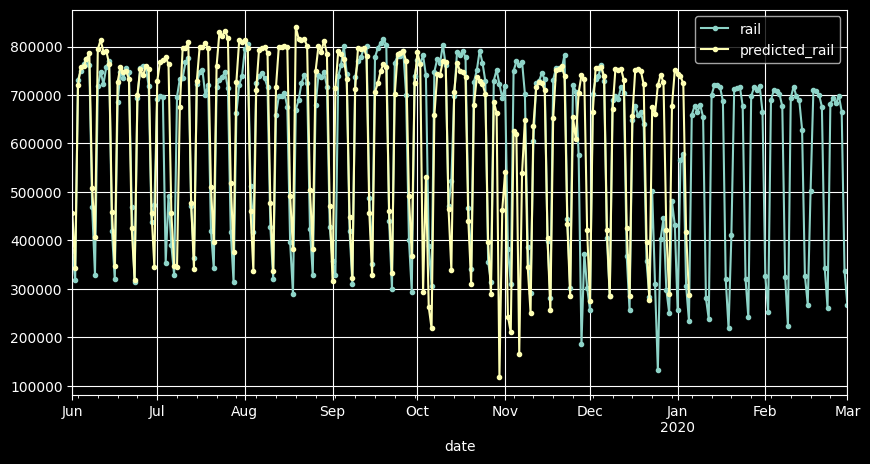

In [5]:
df_test = df_original[test_start_date:][["rail"]]
df_combined = df_test.join(df_test_predictions, how = "left")

df_combined.plot(grid=True, marker=".", figsize=(10, 5))
plt.ticklabel_format(style='plain', axis='y')
plt.show()

<Axes: xlabel='date'>

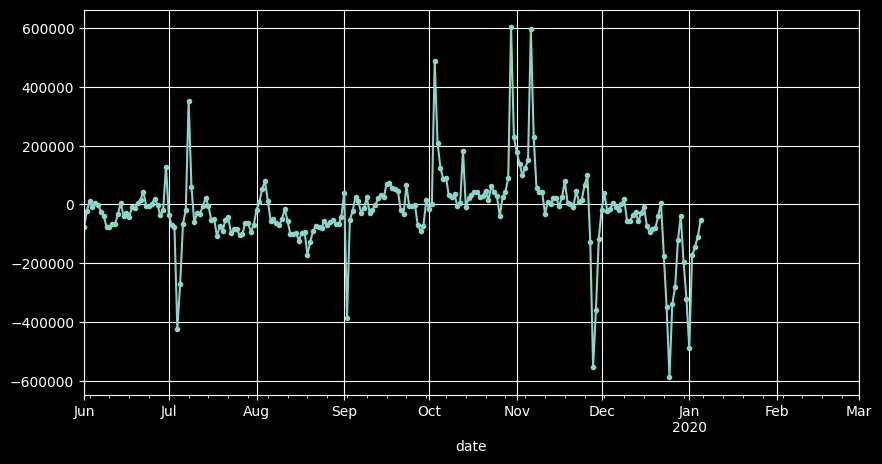

In [7]:
df_combined["error"] = df_combined["rail"] - df_combined["predicted_rail"]
df_combined["error"].plot(grid=True, marker=".", figsize=(10, 5))